# ПРИМЕР 3

## Моделирование плавного изменения напора с шагом 1м.

![модель НРС](imgs/nrs_1.jpg)
Схема НРС состоит из:
* 1 источника в виде насоса ПА
* 2 магистральных рукавных линий
* 2 рукавных разветвлений
* 5 рабочих рукавных линий
* 5 приборов подачи воды

Подключение библиотек

In [26]:
from nrs import NRS_Model, Element, NRS_Revision, NRS_Observer_E    # классы НРС
from nrs import NRS_Data as nd                                      # Табличные данные НРС
from nrs import q_out_nozzle                          # модели расчета параметров
import matplotlib.pyplot as plt                                     # библиотеки для отрисовки получаемых данных

In [27]:
# Вычисляем проводимости гладкоствольных насадков для стволов Б (13мм) и А (19мм)
p_B = NRS_Revision.calc_p(3.7, 40)
p_A = NRS_Revision.calc_p(7.4, 40)

# Эксперименты

## Состав модели:

* Источник (Насос): АЦ-40
* Магистральная рукавная линия (МРЛ Н-Р1): 3 пожарные напорные рукава диаметром 77мм
* Магистральная рукавная линия (МРЛ Р1-Р2): 3 пожарные напорные рукава диаметром 77мм
* Рукавное разветвление (Р1): Стандартное
* Рабочая рукавная линия (РРЛ Р1-Ств1): 3 пожарные напорные рукава диаметром 51мм
* Ствол 1 (Ств1): Ручной ствол "Б"
* Рабочая рукавная линия (РРЛ Р1-Ств2): 1 пожарные напорные рукава диаметром 51мм
* Ствол 2 (Ств2): Ручной ствол "Б"
* Рукавное разветвление (Р2): Стандартное
* Рабочая рукавная линия (РРЛ Р2-Ств3): 1 пожарные напорные рукава диаметром 51мм
* Ствол 3 (Ств3): Ручной ствол "Б"
* Рабочая рукавная линия (РРЛ Р2-Ств4): 1 пожарные напорные рукава диаметром 77мм
* Ствол 4 (Ств4): Ручной ствол "А"
* Рабочая рукавная линия (РРЛ Р2-Ств5): 3 пожарные напорные рукава диаметром 51мм
* Ствол 5 (Ств5): Ручной ствол "Б"

## Эксперимент 1-1


Условия:
* Стартовый напор на насосе - 20м
* На каждой итерации напор увеличивается на 1м
* По достижении напора 100м дополнительно производится 20 итераций расчета для фиксации результата

In [28]:
# Создаем модель НРС
model = NRS_Model('Модель от одного насоса к пяти стволам через два разветвления')

# Создаем элементы модели
pump = Element('Н1', 0, H_add=20)
hoseM_1 = Element('МРЛ Н-Р1', 1, s=nd.ss["77"], n=3)

splitter_1 = Element('Р1', 1, ro=3)                                           # разветвление №1
hoseW_11 = Element('РРЛ Р1-1', 1, s=nd.ss["51"], n=3)                   # рабочая рукавная линия от разветвления №1 к стволу №1
nozzle_11 = Element('Ствол Р1-1(Б)', 2, p=p_B, q_out = q_out_nozzle)  # ствол №1
hoseW_12 = Element('РРЛ Р1-2', 1, s=nd.ss["51"], n=1)                   # рабочая рукавная линия от разветвления №1 к стволу №2
nozzle_12 = Element('Ствол Р1-2(Б)', 2, p=p_B, q_out = q_out_nozzle)  # ствол №2
hoseM_12 = Element('МРЛ Р1-Р2', 1, s=nd.ss["77"], n=3)                  # магистральная рукавная линия №2 - от разветвления №1 к разветвлению №2

splitter_2 = Element('Р2', 1, ro=3)                                           # разветвление №2
hoseW_21 = Element('РРЛ Р2-1', 1, s=nd.ss["51"], n=1)                   # рабочая рукавная линия от разветвления №2 к стволу №3
nozzle_21 = Element('Ствол Р2-1(Б)', 2, p=p_B, q_out = q_out_nozzle)  # ствол №3
hoseW_22 = Element('РРЛ Р2-2', 1, s=nd.ss["77"], n=1)                   # рабочая рукавная линия от разветвления №2 к стволу №4
nozzle_22 = Element('Ствол Р2-2(А)', 2, p=p_A, q_out = q_out_nozzle)   # ствол №4
hoseW_23 = Element('РРЛ Р2-3', 1, s=nd.ss["51"], n=3)                   # рабочая рукавная линия от разветвления №2 к стволу №5
nozzle_23 = Element('Ствол Р2-3(Б)', 2, p=p_B, q_out = q_out_nozzle)  # ствол №5

# Соединяем элементы модели вместе в НРС
pump.append(hoseM_1).append(splitter_1).append(hoseM_12).append(splitter_2)

splitter_1.append(hoseW_11).append(nozzle_11)   # Рукавная линия к стволу №1
splitter_1.append(hoseW_12).append(nozzle_12)   # Рукавная линия к стволу №2

splitter_2.append(hoseW_21).append(nozzle_21)   # Рукавная линия к стволу №3
splitter_2.append(hoseW_22).append(nozzle_22)   # Рукавная линия к стволу №4
splitter_2.append(hoseW_23).append(nozzle_23)   # Рукавная линия к стволу №5

# Добавляем обозревателей
NRS_Observer_E(pump, ['q', 'H_in'])
NRS_Observer_E(nozzle_11, ['q', 'H_in'])
NRS_Observer_E(nozzle_12, ['q', 'H_in'])
NRS_Observer_E(nozzle_21, ['q', 'H_in'])
NRS_Observer_E(nozzle_22, ['q', 'H_in'])
NRS_Observer_E(nozzle_23, ['q', 'H_in'])

# Строим модель и инициируем обозревателей
model.build(pump, interpretate=True)
model.observersInit()

# Расчет НРС:
model.calc(accuracy=0.05, fixStates=True)

# Печать результата расчета
print('Qобщ = ' + str(round(model.summaryQ(), 2)) + 'л/с')

Qобщ = 11.75л/с


In [29]:
# Печать описания модели
NRS_Revision.print_model_elements(model)

Модель от одного насоса к пяти стволам через два разветвления
all:
  Н1
  МРЛ Н-Р1
  Р1
  МРЛ Р1-Р2
  Р2
  РРЛ Р2-1
  Ствол Р2-1(Б)
  РРЛ Р2-2
  Ствол Р2-2(А)
  РРЛ Р2-3
  Ствол Р2-3(Б)
  РРЛ Р1-1
  Ствол Р1-1(Б)
  РРЛ Р1-2
  Ствол Р1-2(Б)
in:
  Н1
out:
  Ствол Р2-1(Б)
  Ствол Р2-2(А)
  Ствол Р2-3(Б)
  Ствол Р1-1(Б)
  Ствол Р1-2(Б)


In [30]:
# Инициация (Обнуление) обозревателей
model = model.observersInit()

In [31]:
# Проведение эксперимента
# Основные итерации
iteration = 0                             # Индекс итерации
iterationCount = 80                       # Количество итераций основного эксперимента
iterationPostCount = 20                   # Количество итераций после эксперимента, для фиксации данных
dbg = False                               # Флаг вывода отладочной информации
pressures = []                            # Список напоров

for i in range(iterationCount+iterationPostCount):
    if dbg:
        print(str(iteration) + "="*10 )
        print('=== Qобщ=' + str(pump.q) + 'л/с')
    
    iteration+=1
    pressures.append(pump.H_in)

    # Расчет модели
    if iteration <= iterationCount:
        pump.H_in += 1
    model.calc()
    print(f'Hвх = {pump.H_in} м, Qобщ = {round(model.summaryQ(), 2)} л/с')

Hвх = 1 м, Qобщ = 12.31 л/с
Hвх = 2 м, Qобщ = 12.38 л/с
Hвх = 3 м, Qобщ = 12.82 л/с
Hвх = 4 м, Qобщ = 12.96 л/с
Hвх = 5 м, Qобщ = 13.32 л/с
Hвх = 6 м, Qобщ = 13.5 л/с
Hвх = 7 м, Qобщ = 13.82 л/с
Hвх = 8 м, Qобщ = 14.02 л/с
Hвх = 9 м, Qобщ = 14.3 л/с
Hвх = 10 м, Qобщ = 14.51 л/с
Hвх = 11 м, Qобщ = 14.77 л/с
Hвх = 12 м, Qобщ = 14.99 л/с
Hвх = 13 м, Qобщ = 15.23 л/с
Hвх = 14 м, Qобщ = 15.45 л/с
Hвх = 15 м, Qобщ = 15.68 л/с
Hвх = 16 м, Qобщ = 15.89 л/с
Hвх = 17 м, Qобщ = 16.11 л/с
Hвх = 18 м, Qобщ = 16.32 л/с
Hвх = 19 м, Qобщ = 16.54 л/с
Hвх = 20 м, Qобщ = 16.74 л/с
Hвх = 21 м, Qобщ = 16.95 л/с
Hвх = 22 м, Qобщ = 17.15 л/с
Hвх = 23 м, Qобщ = 17.35 л/с
Hвх = 24 м, Qобщ = 17.55 л/с
Hвх = 25 м, Qобщ = 17.75 л/с
Hвх = 26 м, Qобщ = 17.94 л/с
Hвх = 27 м, Qобщ = 18.14 л/с
Hвх = 28 м, Qобщ = 18.32 л/с
Hвх = 29 м, Qобщ = 18.51 л/с
Hвх = 30 м, Qобщ = 18.7 л/с
Hвх = 31 м, Qобщ = 18.88 л/с
Hвх = 32 м, Qобщ = 19.07 л/с
Hвх = 33 м, Qобщ = 19.25 л/с
Hвх = 34 м, Qобщ = 19.43 л/с
Hвх = 35 м, Qобщ = 19.6 л/

In [32]:
nozzle_22.history()

{'q': [4.04654039806239,
  4.0660170194849465,
  4.214044786552225,
  4.256697048417238,
  4.379522912432728,
  4.435655946272398,
  4.541778997823552,
  4.605430889860294,
  4.700211127304726,
  4.767750231465911,
  4.854599701059838,
  4.923825064059288,
  5.004941857894135,
  5.074532417241257,
  5.151352128143411,
  5.220528545832833,
  5.2940040395324255,
  5.3623202310174936,
  5.433096246271282,
  5.5003104700962755,
  5.568833286453075,
  5.634828281549949,
  5.701415029822268,
  5.766148509870523,
  5.831031251452574,
  5.8945052452870526,
  5.957859192041911,
  6.020101108839321,
  6.082062823140305,
  6.143113820604414,
  6.203793052675625,
  6.2637009546099565,
  6.323188418163327,
  6.382003462905311,
  6.440376003181108,
  6.498148348819305,
  6.555472425910889,
  6.6122507405509205,
  6.668584816309633,
  6.724415533388933,
  6.779811738657448,
  6.834738715056089,
  6.889244039721468,
  6.9433084533584,
  6.9969656161897005,
  7.0502060018663535,
  7.103054102405608,
  

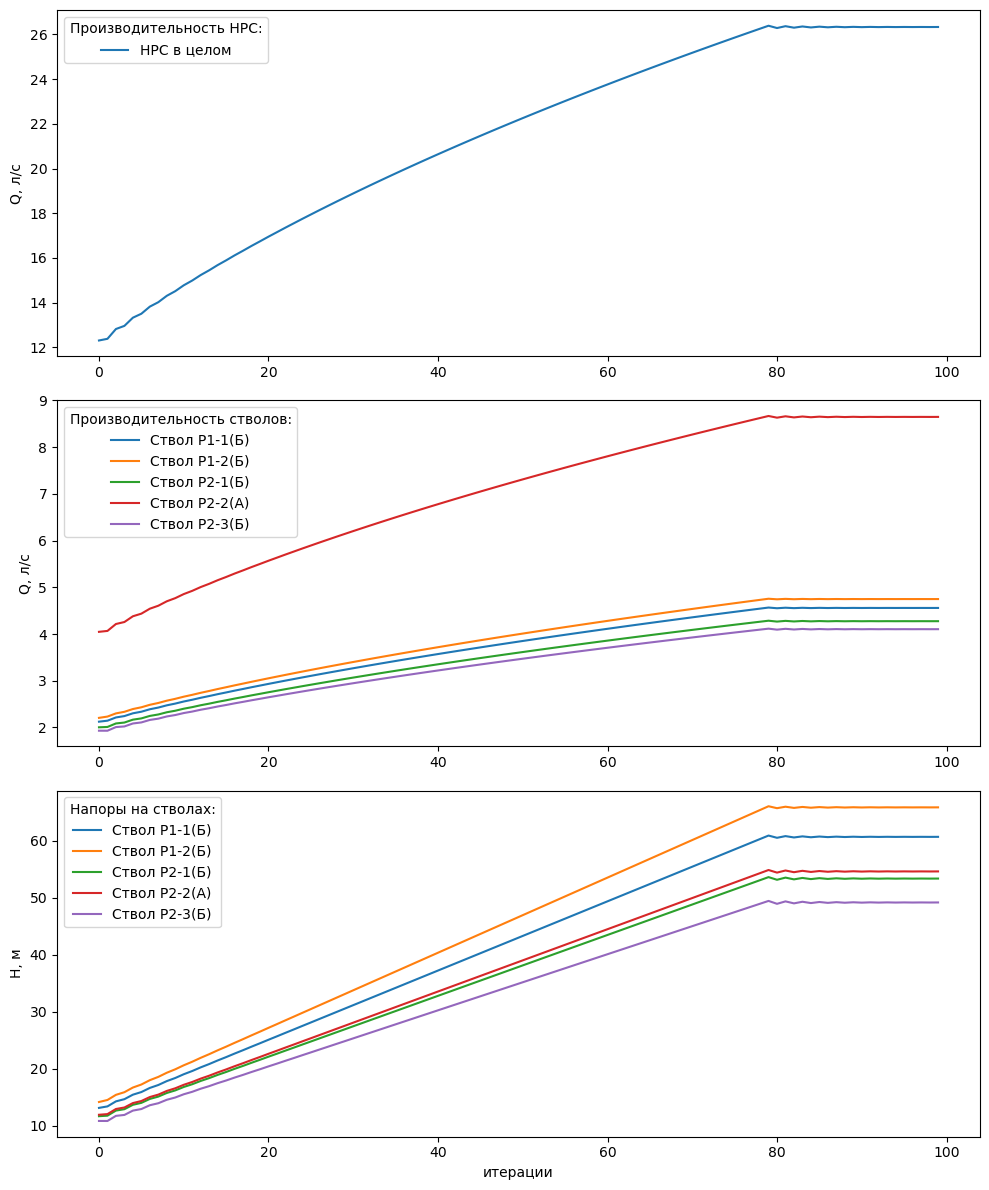

In [33]:
# Выводим итоговые графики:
# Расход всей системы
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))
ax1.plot(pump.history()['q'], label='НРС в целом')

ax1.legend(title='Производительность НРС:')
ax1.set_ylabel('Q, л/с')

# Напоры и расходы на стволах
ax2.plot(nozzle_11.history()['q'], label=nozzle_11.name)
ax2.plot(nozzle_12.history()['q'], label=nozzle_12.name)
ax2.plot(nozzle_21.history()['q'], label=nozzle_21.name)
ax2.plot(nozzle_22.history()['q'], label=nozzle_22.name)
ax2.plot(nozzle_23.history()['q'], label=nozzle_23.name)

ax2.legend(title='Производительность стволов:')
ax2.set_ylabel('Q, л/с')


ax3.plot(nozzle_11.history()['H_in'], label=nozzle_11.name)
ax3.plot(nozzle_12.history()['H_in'], label=nozzle_12.name)
ax3.plot(nozzle_21.history()['H_in'], label=nozzle_21.name)
ax3.plot(nozzle_22.history()['H_in'], label=nozzle_22.name)
ax3.plot(nozzle_23.history()['H_in'], label=nozzle_23.name)

ax3.legend(title='Напоры на стволах:')
ax3.set_xlabel('итерации')
ax3.set_ylabel('Н, м')

fig.tight_layout() 
plt.show()